In [1]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
print("TensorFlow Version:", tf.__version__)

print("GPU Available:")

print(tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU Available:
[]


In [3]:
dataset_path = r"D:\Users\bhaka\Downloads\archive (2)\Dataset"

print("Dataset path:", dataset_path)

print("Does dataset exist?",
      os.path.exists(dataset_path))

Dataset path: D:\Users\bhaka\Downloads\archive (2)\Dataset
Does dataset exist? True


In [4]:
print("Dataset Contents:\n")

for item in os.listdir(dataset_path):
    print(item)

Dataset Contents:

Bus
Car
motorcycle
Truck


In [5]:
class_names = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(
        os.path.join(dataset_path, folder)
    )
])

print("Classes:", class_names)

print("Number of Classes:",
      len(class_names))

Classes: ['Bus', 'Car', 'Truck', 'motorcycle']
Number of Classes: 4


In [6]:
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

total_images = 0

for class_name in class_names:

    class_path = os.path.join(
        dataset_path,
        class_name
    )

    count = len([
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ])

    print(class_name, ":", count)

    total_images += count

print("\nTotal Images:", total_images)

Bus : 100
Car : 100
Truck : 100
motorcycle : 100

Total Images: 400


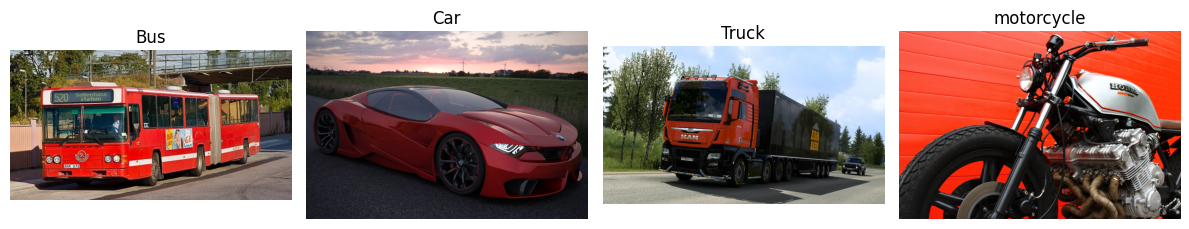

In [7]:
plt.figure(figsize=(12, 5))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(
        dataset_path,
        class_name
    )

    images = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    image_name = random.choice(images)

    image_path = os.path.join(
        class_path,
        image_name
    )

    image = Image.open(image_path)

    plt.subplot(
        1,
        len(class_names),
        i + 1
    )

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [8]:
base_dir = "vehicle_split"

train_dir = os.path.join(
    base_dir,
    "train"
)

validation_dir = os.path.join(
    base_dir,
    "validation"
)

test_dir = os.path.join(
    base_dir,
    "test"
)

os.makedirs(
    train_dir,
    exist_ok=True
)

os.makedirs(
    validation_dir,
    exist_ok=True
)

os.makedirs(
    test_dir,
    exist_ok=True
)

print("Folders created successfully.")

Folders created successfully.


In [9]:
random.seed(42)

for class_name in class_names:

    source_dir = os.path.join(
        dataset_path,
        class_name
    )

    images = [
        file
        for file in os.listdir(source_dir)
        if file.lower().endswith(image_extensions)
    ]

    random.shuffle(images)

    total = len(images)

    train_end = int(
        0.70 * total
    )

    validation_end = int(
        0.85 * total
    )

    train_images = images[:train_end]

    validation_images = images[
        train_end:validation_end
    ]

    test_images = images[
        validation_end:
    ]

    # Create class folders

    os.makedirs(
        os.path.join(
            train_dir,
            class_name
        ),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(
            validation_dir,
            class_name
        ),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(
            test_dir,
            class_name
        ),
        exist_ok=True
    )

    # Copy training images

    for image in train_images:

        shutil.copy2(
            os.path.join(
                source_dir,
                image
            ),

            os.path.join(
                train_dir,
                class_name,
                image
            )
        )

    # Copy validation images

    for image in validation_images:

        shutil.copy2(
            os.path.join(
                source_dir,
                image
            ),

            os.path.join(
                validation_dir,
                class_name,
                image
            )
        )

    # Copy test images

    for image in test_images:

        shutil.copy2(
            os.path.join(
                source_dir,
                image
            ),

            os.path.join(
                test_dir,
                class_name,
                image
            )
        )

    print(
        class_name,
        "→ Train:",
        len(train_images),
        "Validation:",
        len(validation_images),
        "Test:",
        len(test_images)
    )

Bus → Train: 70 Validation: 15 Test: 15
Car → Train: 70 Validation: 15 Test: 15
Truck → Train: 70 Validation: 15 Test: 15
motorcycle → Train: 70 Validation: 15 Test: 15


In [10]:
IMG_HEIGHT = 64
IMG_WIDTH = 64

BATCH_SIZE = 16

print(
    "Image Size:",
    IMG_HEIGHT,
    "x",
    IMG_WIDTH
)

print(
    "Batch Size:",
    BATCH_SIZE
)

Image Size: 64 x 64
Batch Size: 16


In [11]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)

In [12]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(
        IMG_HEIGHT,
        IMG_WIDTH
    ),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=True,

    seed=42
)

Found 280 images belonging to 4 classes.


In [14]:
validation_generator = test_datagen.flow_from_directory(

    validation_dir,

    target_size=(
        IMG_HEIGHT,
        IMG_WIDTH
    ),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 60 images belonging to 4 classes.


In [15]:
test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(
        IMG_HEIGHT,
        IMG_WIDTH
    ),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 60 images belonging to 4 classes.


In [16]:
print(
    "Class Mapping:"
)

print(
    train_generator.class_indices
)

Class Mapping:
{'Bus': 0, 'Car': 1, 'Truck': 2, 'motorcycle': 3}


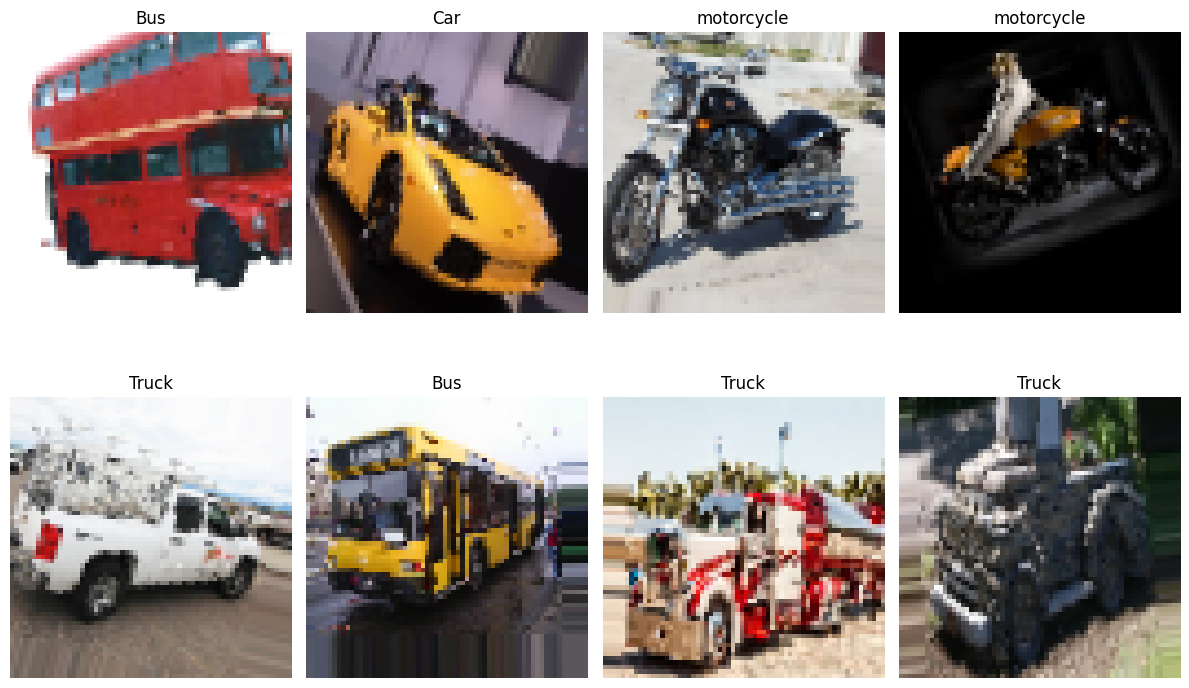

In [17]:
images, labels = next(
    train_generator
)

plt.figure(
    figsize=(12, 8)
)

for i in range(8):

    plt.subplot(
        2,
        4,
        i + 1
    )

    plt.imshow(
        images[i]
    )

    class_index = np.argmax(
        labels[i]
    )

    class_name = class_names[
        class_index
    ]

    plt.title(
        class_name
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [18]:
num_classes = len(
    train_generator.class_indices
)

model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            3
        )
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(
        0.3
    ),

    Dense(
        num_classes,
        activation="softmax"
    )
])

c:\Users\bhaka\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,668 (6.20 MB)

 Trainable params: 1,625,668 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

In [21]:
history = model.fit(

    train_generator,

    epochs=20,

    validation_data=validation_generator
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 599ms/step - accuracy: 0.2750 - loss: 1.4589 - val_accuracy: 0.3167 - val_loss: 1.3817
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 277ms/step - accuracy: 0.3714 - loss: 1.3678 - val_accuracy: 0.4000 - val_loss: 1.3516
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step - accuracy: 0.4071 - loss: 1.2889 - val_accuracy: 0.3000 - val_loss: 1.3021
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 360ms/step - accuracy: 0.5107 - loss: 1.1459 - val_accuracy: 0.4333 - val_loss: 1.2354
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 334ms/step - accuracy: 0.5250 - loss: 1.0954 - val_accuracy: 0.4667 - val_loss: 1.2626
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 504ms/step - accuracy: 0.5536 - loss: 0.9972 - val_accuracy: 0.5000 - val_loss: 1.2828
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 435ms/step - accuracy: 0.6000 - loss: 0.9600 - val_accuracy: 0.5333 - val_loss: 1.1542
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 261ms/step - accuracy: 0.6357 - loss: 0.9152 - val_accuracy: 0

In [24]:
test_loss, test_accuracy = model.evaluate(
    test_generator
)

print(
    "Test Loss:",
    test_loss
)

print(
    "Test Accuracy:",
    test_accuracy
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.6167 - loss: 0.9680
Test Loss: 0.9680055379867554
Test Accuracy: 0.6166666746139526


In [25]:
test_generator.reset()

predictions = model.predict(
    test_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = test_generator.classes

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step


In [26]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(
    "Confusion Matrix:"
)

print(cm)

Confusion Matrix:
[[ 6  3  4  2]
 [ 5  9  1  0]
 [ 3  3  7  2]
 [ 0  0  0 15]]


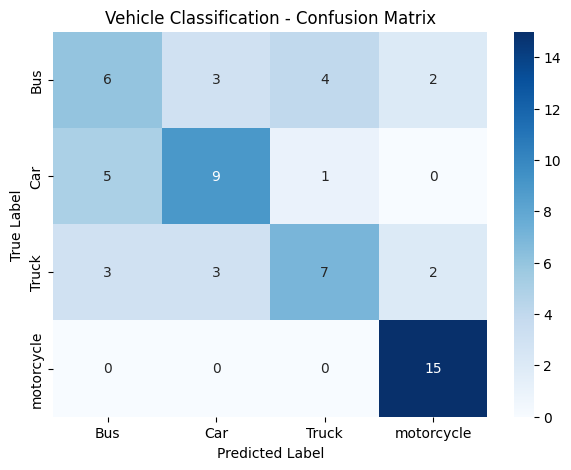

In [27]:
class_labels = list(
    test_generator.class_indices.keys()
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_labels,

    yticklabels=class_labels
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Vehicle Classification - Confusion Matrix"
)

plt.show()

In [28]:
print(
    classification_report(

        y_true,

        y_pred,

        target_names=class_labels
    )
)

              precision    recall  f1-score   support

         Bus       0.43      0.40      0.41        15
         Car       0.60      0.60      0.60        15
       Truck       0.58      0.47      0.52        15
  motorcycle       0.79      1.00      0.88        15

    accuracy                           0.62        60
   macro avg       0.60      0.62      0.60        60
weighted avg       0.60      0.62      0.60        60



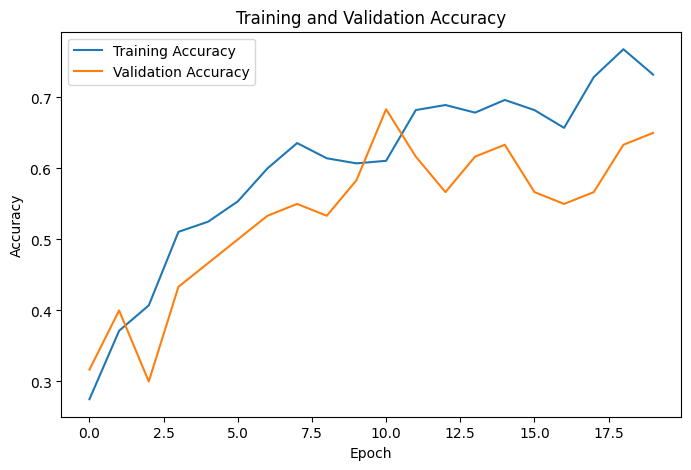

In [29]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.show()

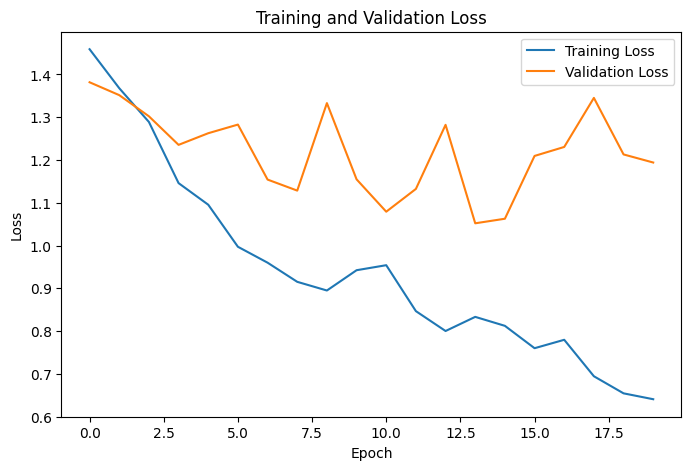

In [30]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()

In [31]:
model.save(
    "vehicle_classification_cnn.keras"
)

print(
    "Model saved successfully!"
)

Model saved successfully!
